First 5 rows of dataset:
   YEAR    JAN    FEB    MAR    APR    MAY    JUN    JUL    AUG    SEP    OCT  \
0  1901  22.40  24.14  29.07  31.91  33.41  33.18  31.21  30.39  30.47  29.97   
1  1902  24.93  26.58  29.77  31.78  33.73  32.91  30.92  30.73  29.80  29.12   
2  1903  23.44  25.03  27.83  31.39  32.91  33.00  31.34  29.98  29.85  29.04   
3  1904  22.50  24.73  28.21  32.02  32.64  32.07  30.36  30.09  30.04  29.20   
4  1905  22.00  22.83  26.68  30.01  33.32  33.25  31.44  30.68  30.12  30.67   

     NOV    DEC  ANNUAL  JAN-FEB  MAR-MAY  JUN-SEP  OCT-DEC  
0  27.31  24.49   28.96    23.27    31.46    31.27    27.25  
1  26.31  24.04   29.22    25.75    31.76    31.09    26.49  
2  26.08  23.65   28.47    24.24    30.71    30.92    26.26  
3  26.36  23.63   28.49    23.62    30.95    30.66    26.40  
4  27.52  23.82   28.30    22.25    30.00    31.33    26.57  

Dataset Shape: (117, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Dat

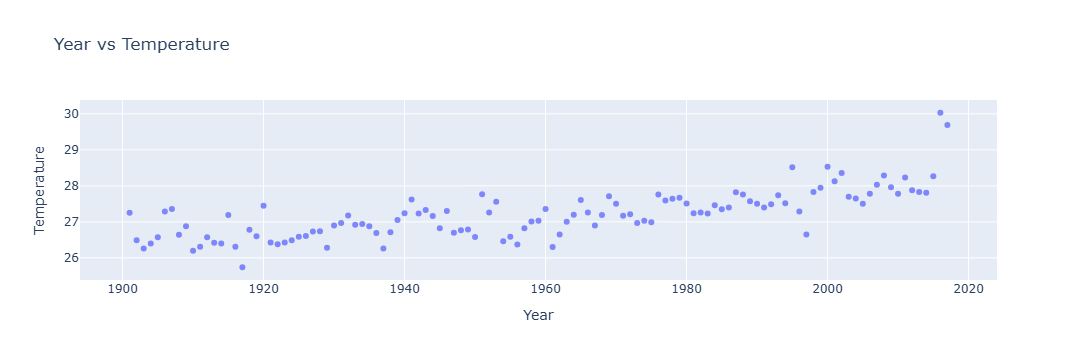


Model Coefficient: 0.014299899012132317
Model Intercept: -0.826608591404618

Model Performance:
Mean Squared Error (MSE): 0.34069261701455855
R² Score: 0.5083958261509928


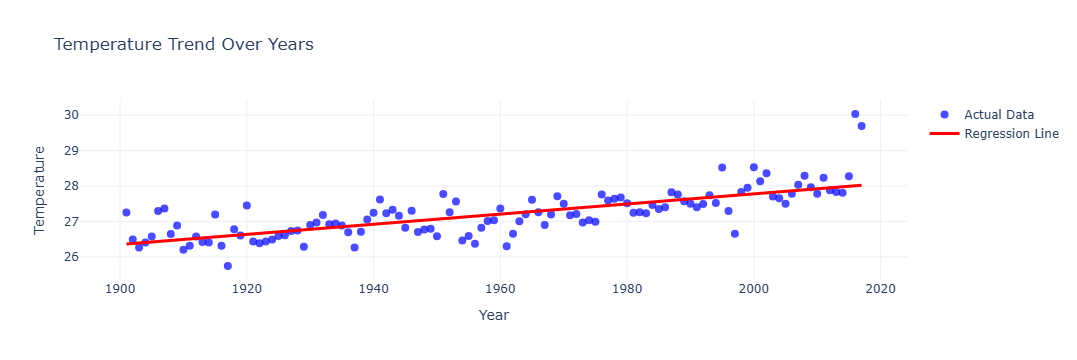


Statsmodels Regression Summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.562
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     147.7
Date:                Tue, 16 Sep 2025   Prob (F-statistic):           2.33e-22
Time:                        09:55:57   Log-Likelihood:                -70.688
No. Observations:                 117   AIC:                             145.4
Df Residuals:                     115   BIC:                             150.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.89


Enter a year to predict temperature:  2100


Predicted Temperature for 2100: 29.20


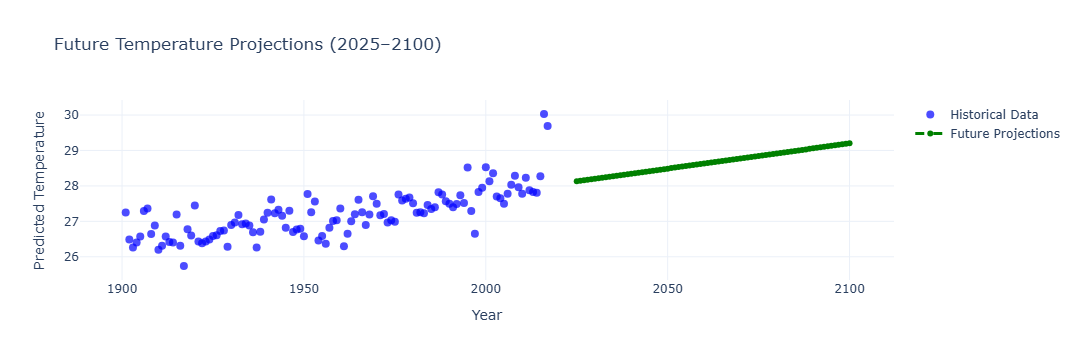

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

df = pd.read_csv("temperatures.csv")

year_col = df.columns[0]
temp_col = df.columns[-1]

print("First 5 rows of dataset:")
print(df.head())
print("\nDataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

fig = px.scatter(
    df,
    x=year_col,
    y=temp_col,
    title="Year vs Temperature",
    labels={year_col: "Year", temp_col: "Temperature"},
    opacity=0.8
)
fig.show()

X = df[[year_col]].values
y = df[temp_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Coefficient:", model.coef_[0])
print("Model Intercept:", model.intercept_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

line_x = df[year_col].values
line_y = model.predict(X)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=df[year_col], y=df[temp_col],
    mode='markers',
    name='Actual Data',
    marker=dict(color='blue', size=8, opacity=0.7)
))
fig2.add_trace(go.Scatter(
    x=line_x, y=line_y,
    mode='lines',
    name='Regression Line',
    line=dict(color='red', width=3)
))
fig2.update_layout(
    title="Temperature Trend Over Years",
    xaxis_title="Year",
    yaxis_title="Temperature",
    template="plotly_white"
)
fig2.show()

X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()
print("\nStatsmodels Regression Summary:")
print(model_sm.summary())

year_input = int(input("\nEnter a year to predict temperature: "))
pred_temp = model.predict(np.array([[year_input]]))
print(f"Predicted Temperature for {year_input}: {pred_temp[0]:.2f}")

future_years = np.arange(2025, 2101).reshape(-1, 1)
future_temps = model.predict(future_years)

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=df[year_col], y=df[temp_col],
    mode='markers',
    name='Historical Data',
    marker=dict(color='blue', size=8, opacity=0.7)
))
fig3.add_trace(go.Scatter(
    x=future_years.flatten(), y=future_temps,
    mode='lines+markers',
    name='Future Projections',
    line=dict(color='green', dash='dash', width=3),
    marker=dict(color='green', size=6)
))
fig3.update_layout(
    title="Future Temperature Projections (2025–2100)",
    xaxis_title="Year",
    yaxis_title="Predicted Temperature",
    template="plotly_white"
)
fig3.show()
